# German Credit Dataset — LDA Assumption Check

**Assumption 4 — No Complete Separation**

Tests whether any linear combination of features can perfectly separate the two credit-risk classes. Linear Discriminant Analysis (LDA) represents the best-case linear separator across all 20 features.

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from scipy.stats import norm as sp_norm
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})
print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Data

In [2]:
ARFF_PATH = 'dataset_31_credit-g.arff'

raw_data, meta = arff.loadarff(ARFF_PATH)
df = pd.DataFrame(raw_data)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.decode('utf-8')

print(f'Loaded: {ARFF_PATH}  |  shape: {df.shape}')

Loaded: dataset_31_credit-g.arff  |  shape: (1000, 21)


---
## 3. Encode Features for LDA

In [3]:
target_col = 'class'

df_enc = df.copy()
le_target = LabelEncoder()
df_enc[target_col] = le_target.fit_transform(df_enc[target_col])

cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != target_col]
for c in cat_cols:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

df_enc = df_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

X = df_enc.drop(columns=[target_col]).values.astype(float)
y = df_enc[target_col].values.astype(int)

print(f'Classes: {le_target.classes_}  ->  {list(range(len(le_target.classes_)))}')
print(f'X shape: {X.shape}')

Classes: ['bad' 'good']  ->  [0, 1]
X shape: (1000, 20)


---
## 4. Fit LDA and Project to 1D

In [4]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y).flatten()

good_idx  = le_target.transform(['good'])[0]
bad_idx   = le_target.transform(['bad'])[0]
good_proj = X_lda[y == good_idx]
bad_proj  = X_lda[y == bad_idx]

print(f'Good credit  —  mean: {good_proj.mean():.3f}  std: {good_proj.std():.3f}  n={len(good_proj)}')
print(f'Bad  credit  —  mean: {bad_proj.mean():.3f}  std: {bad_proj.std():.3f}  n={len(bad_proj)}')

Good credit  —  mean: 0.169  std: 0.975  n=700
Bad  credit  —  mean: -0.395  std: 1.053  n=300


---
## 5. LDA Projection Plot

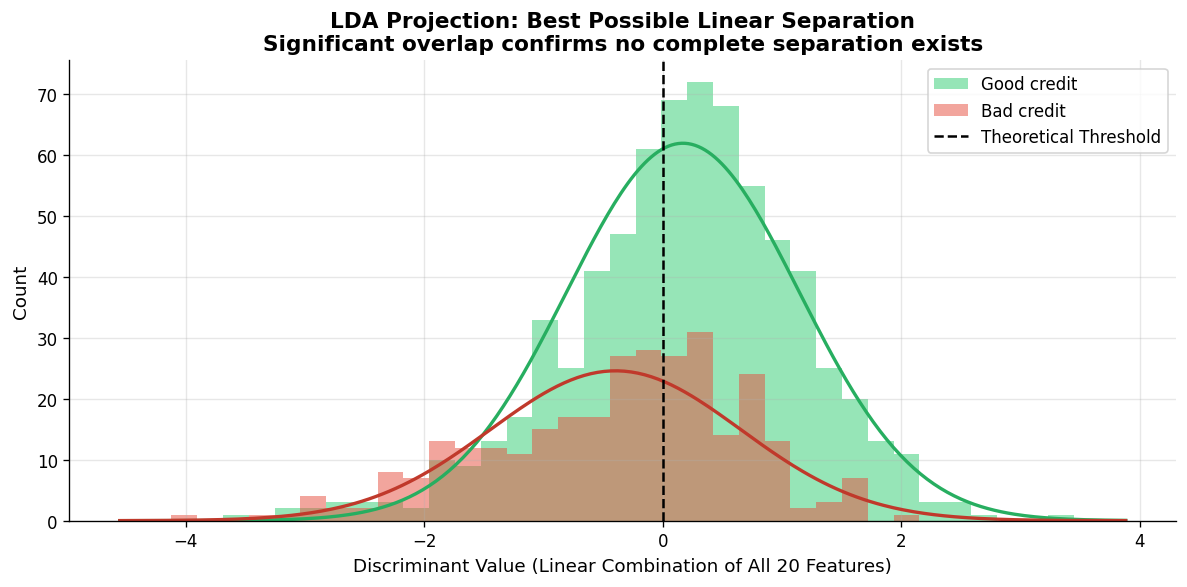

In [5]:
bins  = np.linspace(X_lda.min() - 0.5, X_lda.max() + 0.5, 40)
bin_w = bins[1] - bins[0]
x_range = np.linspace(bins[0], bins[-1], 300)

fig, ax = plt.subplots(figsize=(10, 5))

# Histograms
ax.hist(good_proj, bins=bins, alpha=0.5, color='#2ecc71', label='Good credit')
ax.hist(bad_proj,  bins=bins, alpha=0.5, color='#e74c3c', label='Bad credit')

# Fitted Gaussians
ax.plot(x_range,
        sp_norm.pdf(x_range, good_proj.mean(), good_proj.std()) * len(good_proj) * bin_w,
        color='#27ae60', linewidth=2)
ax.plot(x_range,
        sp_norm.pdf(x_range, bad_proj.mean(),  bad_proj.std())  * len(bad_proj)  * bin_w,
        color='#c0392b', linewidth=2)

# Decision threshold
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Theoretical Threshold')

ax.set_title(
    'LDA Projection: Best Possible Linear Separation\n'
    'Significant overlap confirms no complete separation exists',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Discriminant Value (Linear Combination of All 20 Features)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Quantify Overlap

In [6]:
threshold = 0.0
good_below    = (good_proj < threshold).sum()
bad_above     = (bad_proj  > threshold).sum()
total_overlap = good_below + bad_above

print(f'Good-credit samples below threshold (misclassified) : {good_below}  ({good_below/len(good_proj)*100:.1f}%)')
print(f'Bad-credit  samples above threshold (misclassified) : {bad_above}   ({bad_above/len(bad_proj)*100:.1f}%)')
print(f'Total overlapping samples                           : {total_overlap} / {len(X_lda)} ({total_overlap/len(X_lda)*100:.1f}%)')
print()
print('Verdict: Significant overlap confirmed.')
print('No complete separation exists in the data — Assumption 4 is SATISFIED.')

Good-credit samples below threshold (misclassified) : 278  (39.7%)
Bad-credit  samples above threshold (misclassified) : 119   (39.7%)
Total overlapping samples                           : 397 / 1000 (39.7%)

Verdict: Significant overlap confirmed.
No complete separation exists in the data — Assumption 4 is SATISFIED.
